In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime, timezone, timedelta
import time
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

In [22]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "qwen3:4b"

# Cache settings
CACHE_DIR = Path("data_cache")
CACHE_DURATION_MINUTES = 60

# Create cache directory if it doesn't exist
CACHE_DIR.mkdir(exist_ok=True)

In [23]:
def get_cached_data(symbol, interval, period):
    """Get cached data or download if expired/missing"""
    cache_key = f"{symbol}_{interval}_{period}".replace("=", "_").replace("/", "_")
    cache_file = CACHE_DIR / f"{cache_key}.pkl"
    
    # Check if cache exists and is still valid
    if cache_file.exists():
        cache_age = datetime.now() - datetime.fromtimestamp(cache_file.stat().st_mtime)
        if cache_age < timedelta(minutes=CACHE_DURATION_MINUTES):
            print(f"✓ Using cached data (age: {cache_age.seconds//60}m {cache_age.seconds%60}s)")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)
        else:
            print(f"✗ Cache expired (age: {cache_age.seconds//60}m)")
    
    # Download fresh data
    print(f"⬇ Downloading fresh data for {symbol}...")
    df = yf.download(symbol, interval=interval, period=period, auto_adjust=False)
    
    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # Save to cache
    with open(cache_file, 'wb') as f:
        pickle.dump(df, f)
    
    return df

def get_session():
    hour = datetime.now(timezone.utc).hour
    
    if 7 <= hour < 16:
        return "London"
    elif 13 <= hour < 22:
        return "New York"
    else:
        return "Asian"

In [24]:
def detect_candlestick_patterns(df):
    """Detect candlestick patterns"""
    patterns = []
    
    for i in range(1, len(df)):
        open_price = df['Open'].iloc[i]
        close_price = df['Close'].iloc[i]
        high = df['High'].iloc[i]
        low = df['Low'].iloc[i]
        prev_close = df['Close'].iloc[i-1]
        
        body = abs(close_price - open_price)
        range_size = high - low
        
        if range_size == 0:
            continue
            
        # Doji: very small body
        if body / range_size < 0.1:
            patterns.append({
                'index': i,
                'pattern': 'Doji',
                'signal': 'Indecision',
                'strength': 'Medium'
            })
        
        # Hammer: small body at top, long lower wick
        upper_wick = high - max(open_price, close_price)
        lower_wick = min(open_price, close_price) - low
        
        if lower_wick > 2 * body and upper_wick < body:
            patterns.append({
                'index': i,
                'pattern': 'Hammer',
                'signal': 'Bullish Reversal',
                'strength': 'Strong'
            })
        
        # Shooting Star: small body at bottom, long upper wick
        if upper_wick > 2 * body and lower_wick < body:
            patterns.append({
                'index': i,
                'pattern': 'Shooting Star',
                'signal': 'Bearish Reversal',
                'strength': 'Strong'
            })
        
        # Bullish Engulfing
        if i >= 1:
            prev_open = df['Open'].iloc[i-1]
            prev_close = df['Close'].iloc[i-1]
            
            if (prev_close < prev_open and  # Previous candle bearish
                close_price > open_price and  # Current candle bullish
                open_price < prev_close and   # Opens below previous close
                close_price > prev_open):     # Closes above previous open
                patterns.append({
                    'index': i,
                    'pattern': 'Bullish Engulfing',
                    'signal': 'Bullish Reversal',
                    'strength': 'Very Strong'
                })
            
            # Bearish Engulfing
            if (prev_close > prev_open and  # Previous candle bullish
                close_price < open_price and  # Current candle bearish
                open_price > prev_close and   # Opens above previous close
                close_price < prev_open):     # Closes below previous open
                patterns.append({
                    'index': i,
                    'pattern': 'Bearish Engulfing',
                    'signal': 'Bearish Reversal',
                    'strength': 'Very Strong'
                })
    
    return patterns

In [25]:
def find_support_resistance(df, window=10, threshold=0.0002):
    """Find support and resistance levels"""
    levels = []
    
    # Find local highs and lows
    for i in range(window, len(df) - window):
        # Check if it's a local high
        if df['High'].iloc[i] == df['High'].iloc[i-window:i+window+1].max():
            level = df['High'].iloc[i]
            # Check if level already exists (within threshold)
            if not any(abs(level - l['level']) / level < threshold for l in levels):
                # Count touches
                touches = sum(abs(df['High'] - level) / level < threshold)
                levels.append({
                    'level': level,
                    'type': 'Resistance',
                    'touches': touches,
                    'strength': 'Strong' if touches >= 3 else 'Medium' if touches >= 2 else 'Weak'
                })
        
        # Check if it's a local low
        if df['Low'].iloc[i] == df['Low'].iloc[i-window:i+window+1].min():
            level = df['Low'].iloc[i]
            if not any(abs(level - l['level']) / level < threshold for l in levels):
                touches = sum(abs(df['Low'] - level) / level < threshold)
                levels.append({
                    'level': level,
                    'type': 'Support',
                    'touches': touches,
                    'strength': 'Strong' if touches >= 3 else 'Medium' if touches >= 2 else 'Weak'
                })
    
    # Sort by number of touches
    levels.sort(key=lambda x: x['touches'], reverse=True)
    return levels[:5]  # Return top 5 levels

In [26]:
def analyze_market_structure(df):
    """Analyze market structure (higher highs, lower lows, etc.)"""
    recent = df.tail(20)
    
    highs = recent['High'].values
    lows = recent['Low'].values
    
    # Count higher highs and higher lows
    higher_highs = sum(1 for i in range(1, len(highs)) if highs[i] > highs[i-1])
    lower_lows = sum(1 for i in range(1, len(lows)) if lows[i] < lows[i-1])
    
    # Determine structure
    if higher_highs > lower_lows * 1.5:
        structure = "Uptrend (Higher Highs)"
        bias = "Bullish"
    elif lower_lows > higher_highs * 1.5:
        structure = "Downtrend (Lower Lows)"
        bias = "Bearish"
    else:
        structure = "Consolidation (Ranging)"
        bias = "Neutral"
    
    # Calculate price range
    price_range = (recent['High'].max() - recent['Low'].min()) / recent['Close'].iloc[-1]
    
    return {
        'structure': structure,
        'bias': bias,
        'higher_highs': higher_highs,
        'lower_lows': lower_lows,
        'price_range_pct': price_range * 100
    }

In [27]:
def build_price_action_signal(df, patterns, levels, structure):
    """Build comprehensive price action signal"""
    last = df.iloc[-1]
    current_price = float(last['Close'])
    
    # Get recent patterns (last 5 candles)
    recent_patterns = [p for p in patterns if p['index'] >= len(df) - 5]
    
    # Find nearest support/resistance
    nearest_support = None
    nearest_resistance = None
    
    for level in levels:
        if level['type'] == 'Support' and level['level'] < current_price:
            if nearest_support is None or level['level'] > nearest_support['level']:
                nearest_support = level
        elif level['type'] == 'Resistance' and level['level'] > current_price:
            if nearest_resistance is None or level['level'] < nearest_resistance['level']:
                nearest_resistance = level
    
    # Calculate distance to levels
    dist_to_support = ((current_price - nearest_support['level']) / current_price * 100) if nearest_support else None
    dist_to_resistance = ((nearest_resistance['level'] - current_price) / current_price * 100) if nearest_resistance else None
    
    return {
        'pair': 'EUR/USD',
        'price': current_price,
        'session': get_session(),
        'market_structure': structure['structure'],
        'bias': structure['bias'],
        'price_range_pct': round(structure['price_range_pct'], 2),
        'recent_patterns': [f"{p['pattern']} ({p['signal']})" for p in recent_patterns],
        'nearest_support': round(nearest_support['level'], 5) if nearest_support else None,
        'support_strength': nearest_support['strength'] if nearest_support else None,
        'dist_to_support_pct': round(dist_to_support, 2) if dist_to_support else None,
        'nearest_resistance': round(nearest_resistance['level'], 5) if nearest_resistance else None,
        'resistance_strength': nearest_resistance['strength'] if nearest_resistance else None,
        'dist_to_resistance_pct': round(dist_to_resistance, 2) if dist_to_resistance else None
    }

In [28]:
def analyze_with_ai(signal_data):
    """Use AI to analyze price action signal"""
    prompt = f"""Analyze this forex price action data and provide a trading signal.

Data:
{json.dumps(signal_data, indent=2)}

Respond with JSON only (no explanation):
{{"signal": "BUY or SELL or HOLD", "confidence": 0-100, "reason": "brief reason based on price action", "entry": price, "stop_loss": price, "take_profit": price}}"""
    
    try:
        response = requests.post(
            OLLAMA_URL,
            json={
                "model": MODEL,
                "prompt": prompt,
                "stream": False,
                "format": "json",
                "options": {
                    "temperature": 0.1,
                    "num_predict": 500
                }
            },
            timeout=30
        )
        
        response.raise_for_status()
        response_data = response.json()
        
        raw_response = response_data.get("response", "").strip()
        if not raw_response:
            raw_response = response_data.get("thinking", "").strip()
        
        if not raw_response:
            raise ValueError(f"Empty response from LLM")
        
        try:
            return json.loads(raw_response)
        except json.JSONDecodeError:
            import re
            json_match = re.search(r'\{[^{}]+\}', raw_response, re.DOTALL)
            if json_match:
                return json.loads(json_match.group())
            else:
                raise ValueError(f"No valid JSON found")
    
    except requests.exceptions.ConnectionError:
        raise ConnectionError(f"Cannot connect to Ollama at {OLLAMA_URL}")
    except Exception as e:
        print(f"AI analysis failed: {e}")
        return None

In [29]:
# Fetch and analyze data
df = get_cached_data("EURUSD=X", interval="5m", period="1d")

# Detect patterns and levels
print("🔍 Analyzing price action...\n")
patterns = detect_candlestick_patterns(df)
levels = find_support_resistance(df)
structure = analyze_market_structure(df)

# Build signal
signal = build_price_action_signal(df, patterns, levels, structure)

# Display analysis
print("=" * 70)
print("📊 PRICE ACTION ANALYSIS - EUR/USD")
print("=" * 70)
print()

# Market Structure
print("🏗️  MARKET STRUCTURE:")
print(f"   Structure:       {signal['market_structure']}")
print(f"   Bias:            {signal['bias']} {'📈' if signal['bias'] == 'Bullish' else '📉' if signal['bias'] == 'Bearish' else '↔️'}")
print(f"   Price Range:     {signal['price_range_pct']:.2f}%")
print()

# Current Price
print("💰 CURRENT PRICE:")
print(f"   Price:           {signal['price']:.5f}")
print(f"   Session:         {signal['session']}")
print()

# Support & Resistance
print("🎯 KEY LEVELS:")
if signal['nearest_resistance']:
    print(f"   Resistance:      {signal['nearest_resistance']:.5f} ({signal['resistance_strength']})")
    print(f"   Distance:        +{signal['dist_to_resistance_pct']:.2f}% 🔴")
else:
    print("   Resistance:      None nearby")

if signal['nearest_support']:
    print(f"   Support:         {signal['nearest_support']:.5f} ({signal['support_strength']})")
    print(f"   Distance:        -{signal['dist_to_support_pct']:.2f}% 🟢")
else:
    print("   Support:         None nearby")
print()

# Recent Patterns
print("🕯️  RECENT CANDLESTICK PATTERNS:")
if signal['recent_patterns']:
    for pattern in signal['recent_patterns']:
        print(f"   • {pattern}")
else:
    print("   No significant patterns detected")
print()

# AI Analysis
print("🤖 AI PRICE ACTION ANALYSIS:")
ai_result = analyze_with_ai(signal)

if ai_result:
    signal_emoji = {"BUY": "🟢", "SELL": "🔴", "HOLD": "🟡"}
    ai_signal = ai_result.get('signal', 'UNKNOWN').upper()
    confidence = ai_result.get('confidence', 0)
    
    print(f"   Signal:          {ai_signal} {signal_emoji.get(ai_signal, '⚪')}")
    print(f"   Confidence:      {confidence}%", end="")
    if confidence >= 70:
        print(" (HIGH)")
    elif confidence >= 40:
        print(" (MEDIUM)")
    else:
        print(" (LOW)")
    
    print(f"   Reason:          {ai_result.get('reason', 'N/A')}")
    
    if 'entry' in ai_result:
        print(f"   Entry:           {ai_result.get('entry', 'N/A')}")
        print(f"   Stop Loss:       {ai_result.get('stop_loss', 'N/A')}")
        print(f"   Take Profit:     {ai_result.get('take_profit', 'N/A')}")
else:
    print("   AI analysis unavailable")

print()
print("=" * 70)

# Trading Signal Summary (simple format)
if ai_result and ai_signal != 'HOLD':
    print()
    entry_price = ai_result.get('entry', signal['price'])
    tp_price = ai_result.get('take_profit', 'N/A')
    sl_price = ai_result.get('stop_loss', 'N/A')
    
    # Format prices to 5 decimals if numeric
    if isinstance(entry_price, (int, float)):
        entry_str = f"{entry_price:.5f}"
    else:
        entry_str = str(entry_price)
    
    if isinstance(tp_price, (int, float)):
        tp_str = f"{tp_price:.5f}"
    else:
        tp_str = str(tp_price)
    
    if isinstance(sl_price, (int, float)):
        sl_str = f"{sl_price:.5f}"
    else:
        sl_str = str(sl_price)
    
    print(f"EURUSD {ai_signal.capitalize()} {entry_str} / TP : {tp_str} / SL : {sl_str}")
    print()


✓ Using cached data (age: 10m 49s)
🔍 Analyzing price action...

📊 PRICE ACTION ANALYSIS - EUR/USD

🏗️  MARKET STRUCTURE:
   Structure:       Downtrend (Lower Lows)
   Bias:            Bearish 📉
   Price Range:     0.12%

💰 CURRENT PRICE:
   Price:           1.15607
   Session:         London

🎯 KEY LEVELS:
   Resistance:      1.15701 (Strong)
   Distance:        +0.08% 🔴
   Support:         1.15594 (Strong)
   Distance:        -0.01% 🟢

🕯️  RECENT CANDLESTICK PATTERNS:
   No significant patterns detected

🤖 AI PRICE ACTION ANALYSIS:
   Signal:          UNKNOWN ⚪
   Confidence:      0% (LOW)
   Reason:          N/A


EURUSD Unknown 1.15607 / TP : N/A / SL : N/A



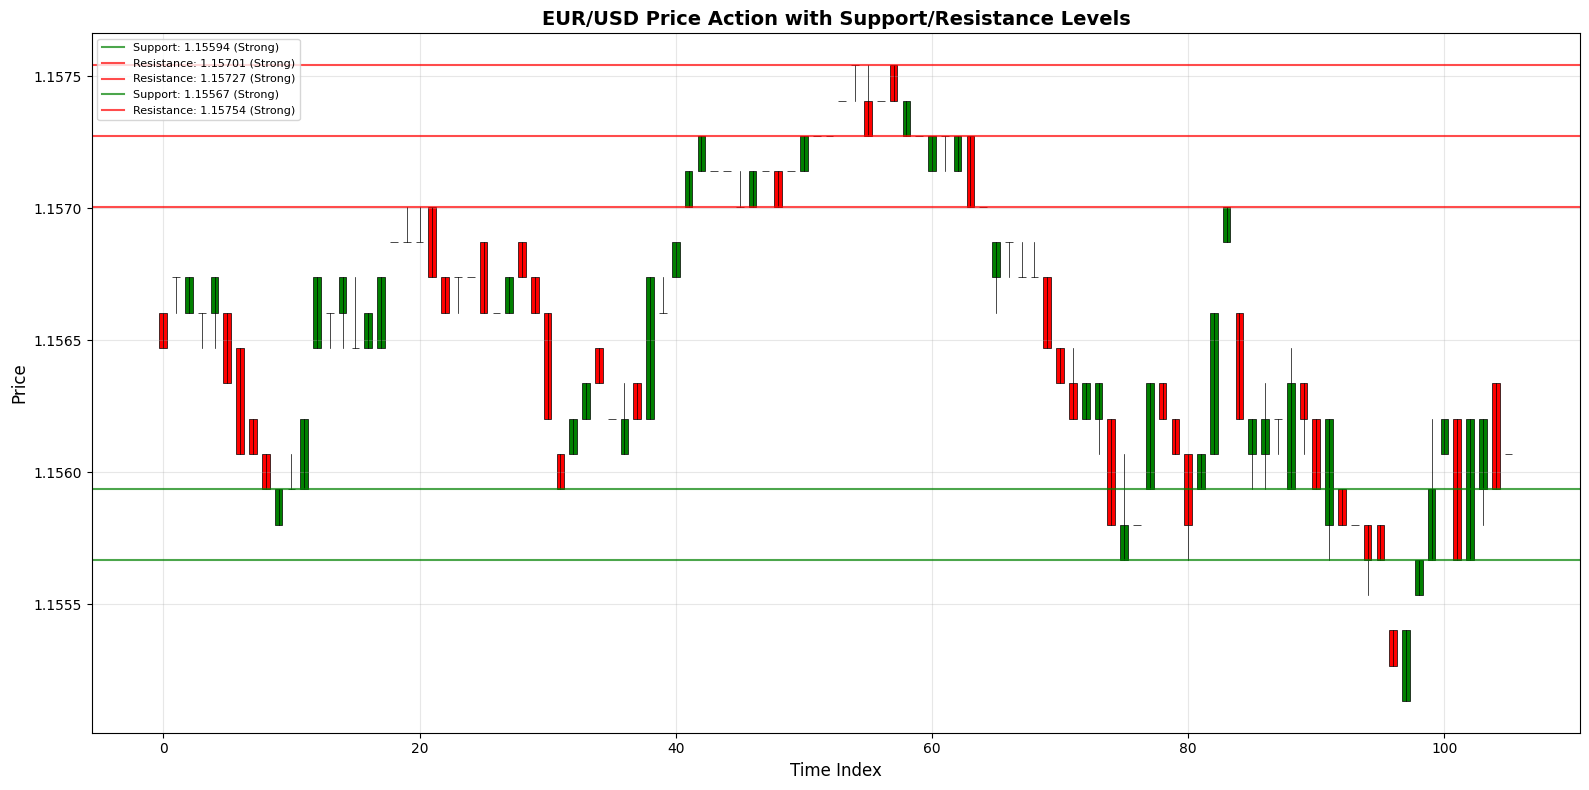

In [30]:
# Visualize price action with support/resistance
fig, ax = plt.subplots(figsize=(16, 8))

# Plot candlesticks
for i in range(len(df)):
    open_price = df['Open'].iloc[i]
    close_price = df['Close'].iloc[i]
    high = df['High'].iloc[i]
    low = df['Low'].iloc[i]
    
    # Color
    color = 'green' if close_price > open_price else 'red'
    
    # Wicks
    ax.plot([i, i], [low, high], color='black', linewidth=0.5)
    
    # Body
    height = abs(close_price - open_price)
    bottom = min(open_price, close_price)
    rect = Rectangle((i - 0.3, bottom), 0.6, height, facecolor=color, edgecolor='black', linewidth=0.5)
    ax.add_patch(rect)

# Plot support/resistance levels
for level in levels:
    color = 'red' if level['type'] == 'Resistance' else 'green'
    linestyle = '-' if level['strength'] == 'Strong' else '--' if level['strength'] == 'Medium' else ':'
    ax.axhline(y=level['level'], color=color, linestyle=linestyle, alpha=0.7, 
               label=f"{level['type']}: {level['level']:.5f} ({level['strength']})")

# Highlight recent patterns
for pattern in patterns:
    if pattern['index'] >= len(df) - 10:  # Last 10 candles
        idx = pattern['index']
        ax.text(idx, df['High'].iloc[idx] + 0.0001, pattern['pattern'], 
                fontsize=8, ha='center', rotation=45)

ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.set_title('EUR/USD Price Action with Support/Resistance Levels', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()